# PROJET DEEP LEARNING : PROJET GAN sur la dataset Fashion Minst 

## ETAPE 1: Importation des biblio

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## ETAPE 2: Chargement de la dataset

In [ ]:
(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

## ETAPE 3: Normalisation et definition des constants

In [ ]:
# Normalize the images to the range [-1, 1]
train_images = (train_images - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1)

# Constants
BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 50
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 1

## ETAPE 4: Generator et Discriminator

In [ ]:
# Prepare the dataset
dataset = tf.data.Dataset.from_tensor_slices(train_images)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Generator model
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(NOISE_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

# Discriminator model
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

## ETAPE 5: Real/fake

In [ ]:
# Loss and optimizers
def discriminator_loss(real_output, fake_output):
    real_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(real_output), real_output)
    fake_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(fake_output), fake_output)

# Instantiate models
generator = make_generator_model()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


## ETAPE 6:  Boucle D'Entrainement

In [ ]:
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)

        # Generate and save images every 10 epochs
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(generator, epoch + 1, seed)

        print(f'Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}')


## ETAPE 7: Generation et stokage des images

In [ ]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

## ETAPE FINALE: Entrainement GAN

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


C:\Users\marou\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\marou\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1, Gen Loss: 0.9002, Disc Loss: 1.2333
Epoch 2, Gen Loss: 0.9854, Disc Loss: 1.1414
Epoch 3, Gen Loss: 0.7457, Disc Loss: 1.4530
Epoch 4, Gen Loss: 0.8710, Disc Loss: 1.4014
Epoch 5, Gen Loss: 0.7955, Disc Loss: 1.2382
Epoch 6, Gen Loss: 0.9095, Disc Loss: 1.2175
Epoch 7, Gen Loss: 0.8610, Disc Loss: 1.3037
Epoch 8, Gen Loss: 0.7858, Disc Loss: 1.4663
Epoch 9, Gen Loss: 0.9346, Disc Loss: 1.1187


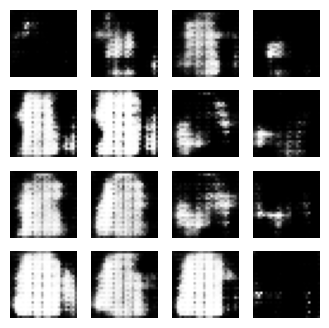

Epoch 10, Gen Loss: 1.2334, Disc Loss: 0.7392
Epoch 11, Gen Loss: 0.7542, Disc Loss: 1.5643
Epoch 12, Gen Loss: 1.1032, Disc Loss: 1.2324
Epoch 13, Gen Loss: 1.3036, Disc Loss: 0.8066
Epoch 14, Gen Loss: 1.1633, Disc Loss: 1.0565
Epoch 15, Gen Loss: 1.0084, Disc Loss: 1.2277
Epoch 16, Gen Loss: 1.0516, Disc Loss: 1.0540
Epoch 17, Gen Loss: 1.0951, Disc Loss: 1.0278
Epoch 18, Gen Loss: 1.1892, Disc Loss: 1.0776
Epoch 19, Gen Loss: 1.1196, Disc Loss: 1.1774


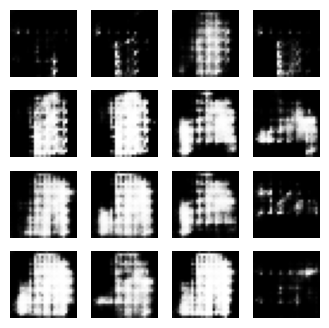

Epoch 20, Gen Loss: 1.9181, Disc Loss: 0.6940
Epoch 21, Gen Loss: 1.4181, Disc Loss: 0.8197
Epoch 22, Gen Loss: 1.2080, Disc Loss: 0.9884
Epoch 23, Gen Loss: 1.4576, Disc Loss: 0.8804
Epoch 24, Gen Loss: 1.8179, Disc Loss: 0.7255
Epoch 25, Gen Loss: 1.4267, Disc Loss: 0.8379
Epoch 26, Gen Loss: 2.0231, Disc Loss: 0.6430
Epoch 27, Gen Loss: 1.8321, Disc Loss: 0.5921
Epoch 28, Gen Loss: 1.6341, Disc Loss: 0.7309
Epoch 29, Gen Loss: 2.0112, Disc Loss: 0.7256


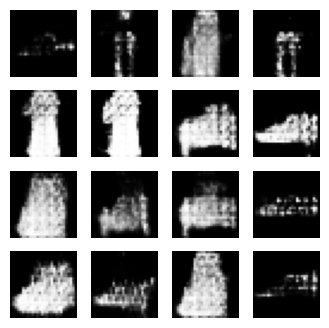

Epoch 30, Gen Loss: 1.7032, Disc Loss: 0.7172
Epoch 31, Gen Loss: 1.4729, Disc Loss: 0.7870
Epoch 32, Gen Loss: 1.5663, Disc Loss: 0.8026
Epoch 33, Gen Loss: 1.3162, Disc Loss: 0.7238
Epoch 34, Gen Loss: 1.7733, Disc Loss: 0.8458
Epoch 35, Gen Loss: 1.6585, Disc Loss: 1.1143
Epoch 36, Gen Loss: 1.3224, Disc Loss: 1.0259
Epoch 37, Gen Loss: 1.6636, Disc Loss: 1.0096
Epoch 38, Gen Loss: 1.7922, Disc Loss: 0.7838
Epoch 39, Gen Loss: 1.6394, Disc Loss: 0.8694


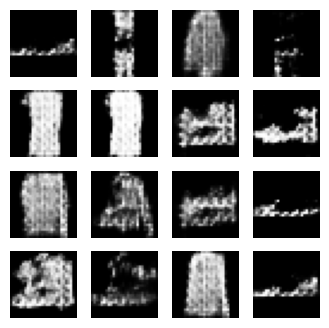

Epoch 40, Gen Loss: 1.5311, Disc Loss: 0.8625
Epoch 41, Gen Loss: 1.5051, Disc Loss: 0.9508
Epoch 42, Gen Loss: 1.9028, Disc Loss: 0.5186
Epoch 43, Gen Loss: 1.3537, Disc Loss: 0.9895
Epoch 44, Gen Loss: 1.5053, Disc Loss: 0.9174
Epoch 45, Gen Loss: 1.8208, Disc Loss: 0.8662
Epoch 46, Gen Loss: 1.5825, Disc Loss: 0.8280
Epoch 47, Gen Loss: 1.4542, Disc Loss: 0.9023
Epoch 48, Gen Loss: 1.6122, Disc Loss: 1.0048
Epoch 49, Gen Loss: 1.4985, Disc Loss: 0.8861


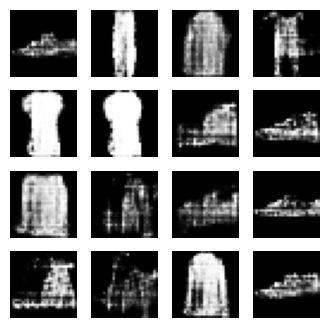

Epoch 50, Gen Loss: 1.6770, Disc Loss: 0.7938


In [1]:
train(dataset, EPOCHS)

In [2]:
from PIL import Image, ImageEnhance

def enhance_generated_images(epoch):
    # Load the saved image
    input_image_path = f"image_at_epoch_{epoch:04d}.png"
    image = Image.open(input_image_path)

    # Apply sharpening filter
    sharpener = ImageEnhance.Sharpness(image)
    sharpened_image = sharpener.enhance(2.0)  # Enhance sharpness by a factor of 2

    # Save and display
    output_image_path = f"sharpened_image_epoch_{epoch:04d}.png"
    sharpened_image.save(output_image_path)
    sharpened_image.show()

# Example usage for the last epoch
enhance_generated_images(50)
